In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Aesthetic defaults — keep plots clean throughout
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("Environment ready.")

Environment ready.


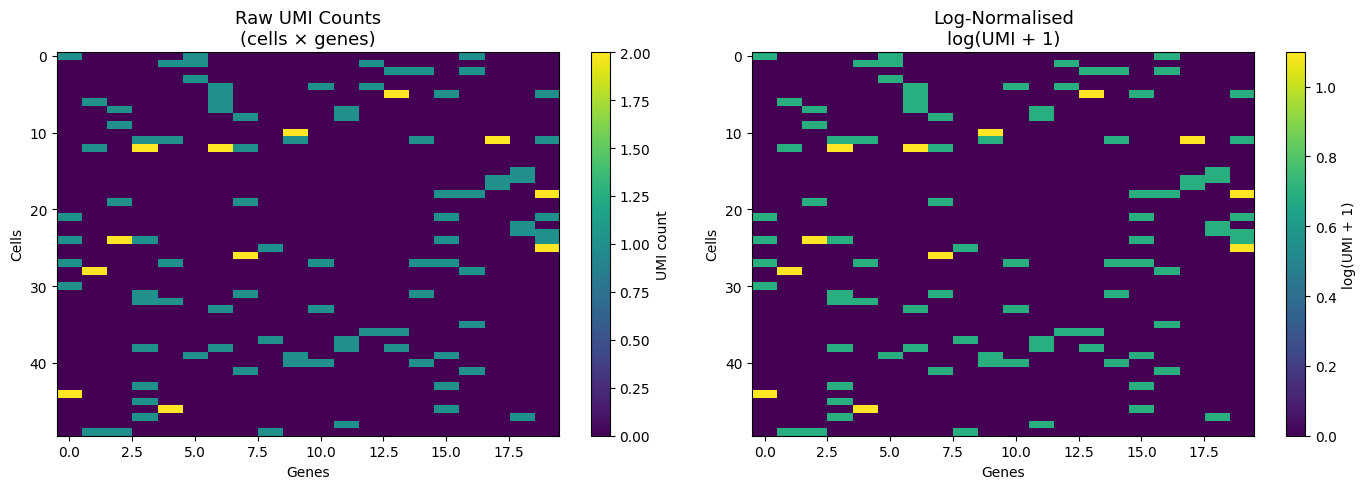

Matrix shape: (50, 20)
Sparsity: 89.7% zeros
Mean counts per cell: 2.3


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_cells, n_genes = 50, 20

# Negative binomial is the standard distribution for UMI counts
# It captures the overdispersion you see in real scRNA-seq data
expression = np.random.negative_binomial(n=1, p=0.9, size=(n_cells, n_genes)).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(expression, aspect='auto', cmap='viridis', interpolation='none')
axes[0].set_title("Raw UMI Counts\n(cells × genes)", fontsize=13)
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Cells")
plt.colorbar(im, ax=axes[0], label="UMI count")

log_expression = np.log1p(expression)
im2 = axes[1].imshow(log_expression, aspect='auto', cmap='viridis', interpolation='none')
axes[1].set_title("Log-Normalised\nlog(UMI + 1)", fontsize=13)
axes[1].set_xlabel("Genes")
axes[1].set_ylabel("Cells")
plt.colorbar(im2, ax=axes[1], label="log(UMI + 1)")

plt.tight_layout()
plt.show()

sparsity = (expression == 0).sum() / expression.size
print(f"Matrix shape: {expression.shape}")
print(f"Sparsity: {sparsity:.1%} zeros")
print(f"Mean counts per cell: {expression.sum(axis=1).mean():.1f}")

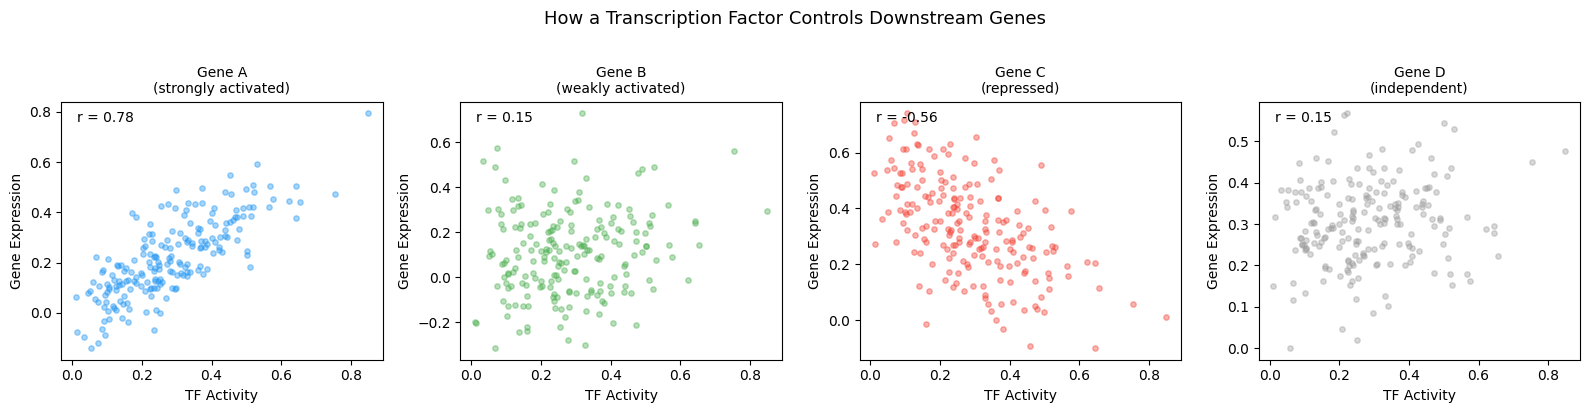

In [3]:
np.random.seed(0)
n_cells = 200

tf_activity = np.random.beta(a=2, b=5, size=n_cells)

gene_a = 0.8 * tf_activity + 0.1 * np.random.randn(n_cells)
gene_b = 0.3 * tf_activity + 0.2 * np.random.randn(n_cells)
gene_c = -0.6 * tf_activity + 0.15 * np.random.randn(n_cells) + 0.5
gene_d = 0.1 * np.random.randn(n_cells) + 0.3

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, gene, label, color in zip(
    axes,
    [gene_a, gene_b, gene_c, gene_d],
    ['Gene A\n(strongly activated)', 'Gene B\n(weakly activated)',
     'Gene C\n(repressed)', 'Gene D\n(independent)'],
    ['#2196F3', '#4CAF50', '#F44336', '#9E9E9E']
):
    ax.scatter(tf_activity, gene, alpha=0.4, s=15, color=color)
    ax.set_xlabel("TF Activity", fontsize=10)
    ax.set_ylabel("Gene Expression", fontsize=10)
    ax.set_title(label, fontsize=10)
    corr = np.corrcoef(tf_activity, gene)[0, 1]
    ax.text(0.05, 0.92, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=10)

plt.suptitle("How a Transcription Factor Controls Downstream Genes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()